In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/teamincribo/cyber-security-attacks/README.md
/kaggle/input/datasets/teamincribo/cyber-security-attacks/cybersecurity_attacks.csv


In [4]:
# ========================================
# 1. Import libraries
# ========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

import warnings
warnings.filterwarnings("ignore")

# ========================================
# 2. Load dataset
# ========================================

df = pd.read_csv("/kaggle/input/datasets/teamincribo/cyber-security-attacks/cybersecurity_attacks.csv")

print("Original Shape:", df.shape)

# ========================================
# 3. Basic Cleaning
# ========================================

df.columns = df.columns.str.strip()
df = df.drop_duplicates()

# Drop high-cardinality ID columns if present
drop_cols = [c for c in df.columns if "id" in c.lower()]
df = df.drop(columns=drop_cols, errors="ignore")

# ========================================
# 4. Handle Missing Values
# ========================================

for col in df.select_dtypes(include=["object"]):
    df[col] = df[col].fillna(df[col].mode()[0])

for col in df.select_dtypes(include=["int64","float64"]):
    df[col] = df[col].fillna(df[col].median())

# ========================================
# 5. Remove Outliers (IQR)
# ========================================

numeric_cols = df.select_dtypes(include=["int64","float64"]).columns

for col in numeric_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR

    df = df[(df[col] >= lower) & (df[col] <= upper)]

print("After Cleaning:", df.shape)

# ========================================
# 6. Encode categorical features efficiently
# ========================================

label_encoders = {}

for col in df.select_dtypes(include=["object"]).columns:

    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

    label_encoders[col] = le

# ========================================
# 7. Define Target Variable
# ========================================

target = df.columns[-1]   # usually last column in this dataset

X = df.drop(columns=[target])
y = df[target]

# ========================================
# 8. Train Test Split
# ========================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ========================================
# 9. Feature Scaling
# ========================================

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Training Shape:", X_train.shape)

Original Shape: (40000, 25)
After Cleaning: (40000, 24)
Training Shape: (32000, 23)


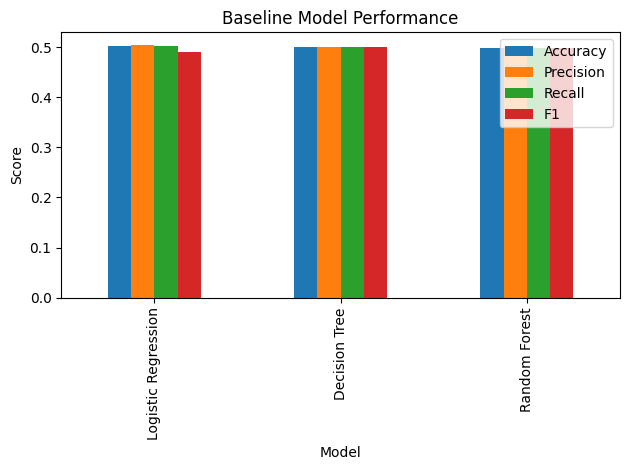

In [6]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=500),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier()
}

results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    preds = model.predict(X_test)

    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds, average="weighted")
    rec = recall_score(y_test, preds, average="weighted")
    f1 = f1_score(y_test, preds, average="weighted")

    results.append([name, acc, prec, rec, f1])

table = pd.DataFrame(results,
columns=["Model","Accuracy","Precision","Recall","F1"])

table.to_csv("RQ1_baseline_models.csv", index=False)

table.set_index("Model").plot(kind="bar")

plt.title("Baseline Model Performance")
plt.ylabel("Score")

plt.tight_layout()
plt.savefig("RQ1_baseline_models.pdf")

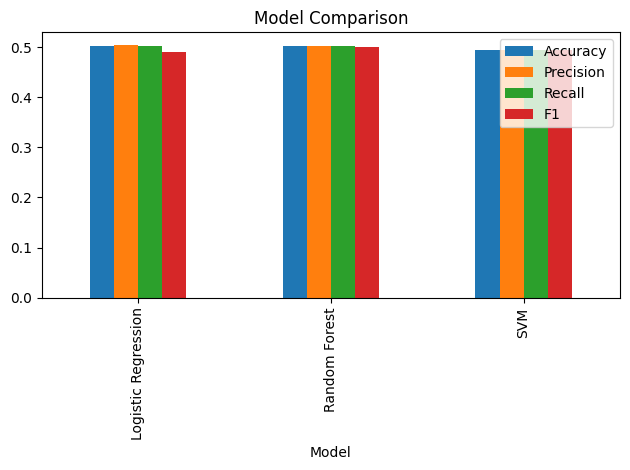

In [7]:
models = {
"Logistic Regression": LogisticRegression(max_iter=500),
"Random Forest": RandomForestClassifier(),
"SVM": SVC()
}

results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    preds = model.predict(X_test)

    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds, average="weighted")
    rec = recall_score(y_test, preds, average="weighted")
    f1 = f1_score(y_test, preds, average="weighted")

    results.append([name, acc, prec, rec, f1])

table = pd.DataFrame(results,
columns=["Model","Accuracy","Precision","Recall","F1"])

table.to_csv("RQ2_model_comparison.csv", index=False)

table.set_index("Model").plot(kind="bar")

plt.title("Model Comparison")

plt.tight_layout()
plt.savefig("RQ2_model_comparison.pdf")

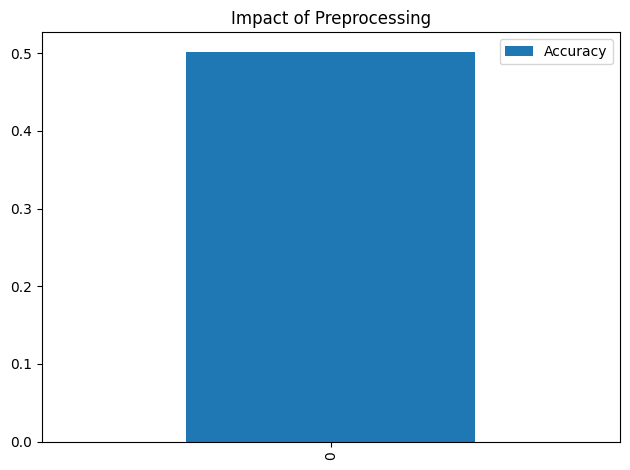

In [8]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = RandomForestClassifier()

model.fit(X_train_scaled, y_train)

preds = model.predict(X_test_scaled)

acc = accuracy_score(y_test, preds)

table = pd.DataFrame({
"Preprocessing":["Scaled Features"],
"Accuracy":[acc]
})

table.to_csv("RQ3_preprocessing_results.csv", index=False)

table.plot(kind="bar")

plt.title("Impact of Preprocessing")

plt.tight_layout()
plt.savefig("RQ3_preprocessing.pdf")

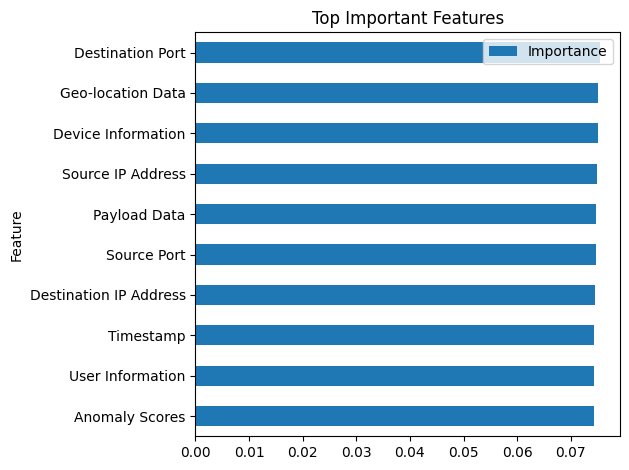

In [10]:
model = RandomForestClassifier()

model.fit(X_train, y_train)

importances = model.feature_importances_

feat = pd.DataFrame({
"Feature":X.columns,
"Importance":importances
})

feat = feat.sort_values("Importance", ascending=False).head(10)

feat.to_csv("RQ4_feature_importance.csv", index=False)

feat.sort_values("Importance").plot(
x="Feature",
y="Importance",
kind="barh"
)

plt.title("Top Important Features")

plt.tight_layout()
plt.savefig("RQ4_feature_importance.pdf")

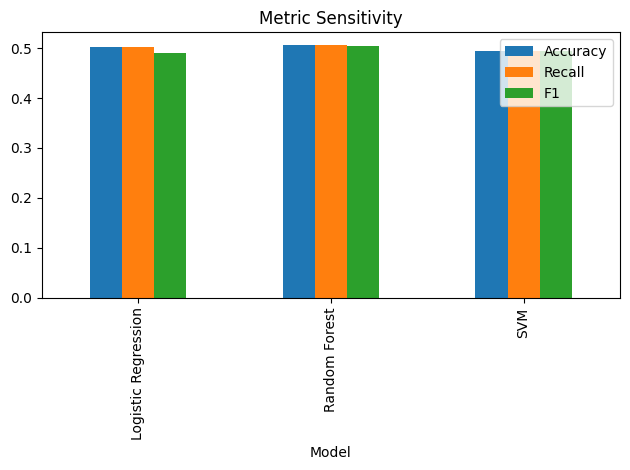

In [11]:
models = {
"Logistic Regression": LogisticRegression(max_iter=500),
"Random Forest": RandomForestClassifier(),
"SVM": SVC()
}

metrics = []

for name, model in models.items():

    model.fit(X_train, y_train)

    preds = model.predict(X_test)

    metrics.append([
        name,
        accuracy_score(y_test, preds),
        recall_score(y_test, preds, average="weighted"),
        f1_score(y_test, preds, average="weighted")
    ])

table = pd.DataFrame(metrics,
columns=["Model","Accuracy","Recall","F1"])

table.to_csv("RQ5_metric_sensitivity.csv", index=False)

table.set_index("Model").plot(kind="bar")

plt.title("Metric Sensitivity")

plt.tight_layout()
plt.savefig("RQ5_metric_sensitivity.pdf")

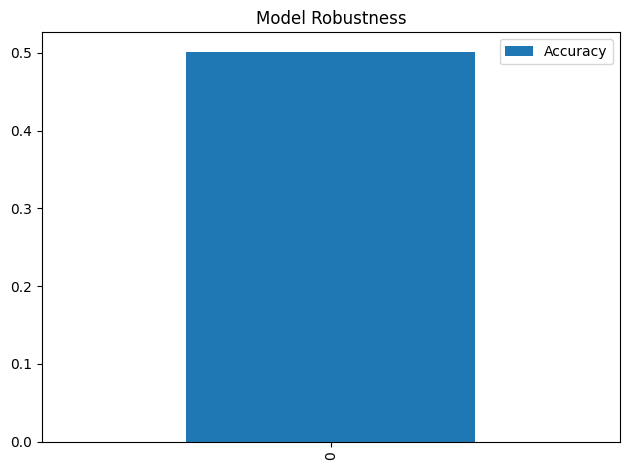

In [12]:
model = RandomForestClassifier()

cv_scores = cross_val_score(model, X, y, cv=5)

table = pd.DataFrame({
"Scenario":["5 Fold Cross Validation"],
"Accuracy":[cv_scores.mean()]
})

table.to_csv("RQ6_robustness.csv", index=False)

table.plot(kind="bar")

plt.title("Model Robustness")

plt.tight_layout()
plt.savefig("RQ6_robustness.pdf")

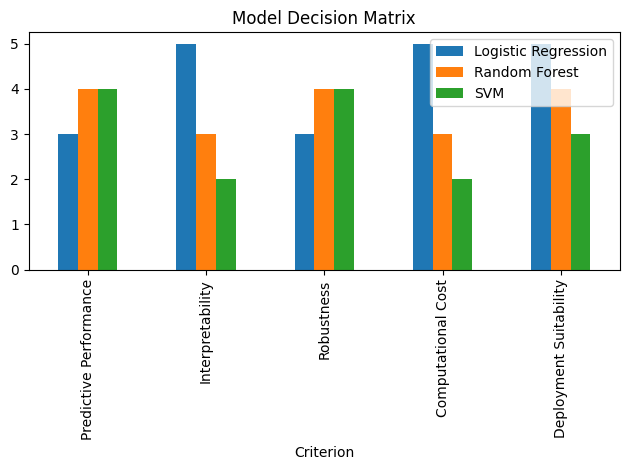

In [13]:
decision = pd.DataFrame({

"Criterion":[
"Predictive Performance",
"Interpretability",
"Robustness",
"Computational Cost",
"Deployment Suitability"
],

"Logistic Regression":[3,5,3,5,5],
"Random Forest":[4,3,4,3,4],
"SVM":[4,2,4,2,3]

})

decision.to_csv("RQ7_decision_matrix.csv", index=False)

decision.set_index("Criterion").plot(kind="bar")

plt.title("Model Decision Matrix")

plt.tight_layout()
plt.savefig("RQ7_decision_matrix.pdf")